# Training and evaluating statistical Modells
ARIMA, SARIMA and

Evaluating with AIC, MAE, ...

In [73]:
#load needed packages
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.models import ARIMA
import matplotlib.pyplot as plt
from matplotlib.pyplot import ylabel, xlabel
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

In [5]:
#read and prepare
data = pd.read_csv('data_cleaned.csv')
data['Unnamed: 0']= pd.to_datetime(data['Unnamed: 0'])
data.set_index('Unnamed: 0', inplace=True)

<Axes: xlabel='Unnamed: 0'>

<Figure size 2100x700 with 0 Axes>

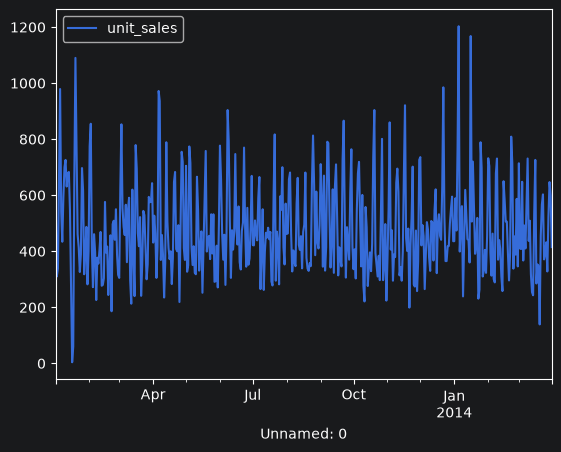

In [19]:
#visualize data
plt.figure(figsize=(21, 7))
data.plot()              ####label hinzufügen

In [10]:
# Split data (after 80% for training split)
#train, test = series.split_after(0.8)
#I want to split at a specific time:
train = data[data.index<'2014-01-01']
test = data[data.index>='2014-01-01']

#change to a timeseries object
train = TimeSeries.from_dataframe(train, value_cols='unit_sales')
test = TimeSeries.from_dataframe(test, value_cols='unit_sales')

## ARIMA

In [35]:
#ADF test to check for stationary. Null hypothesis: it is not stationary(for p>0,05)

# adfuller() doesn't work directly with timeseriesobjects. To extract the values:
train_val = train.values().flatten()   # Bei univariater Serie in 1D umwandeln
test_val = test.values().flatten()      #need this for later

# ADF-Test
result = adfuller(arr) #sonst mit arr

if result[1] >= 0.05:
   print(f'Timeseries is not stationary: p= {result[1]}')
else:
    print(f'Timeseries is stationary: p= {result[1]}')


Timeseries is stationary: p= 0.0006123184685637161


In [ ]:
'''
#we don't have to differentiate, but if we did, here's the code
# First Differentiation – new train-series with which we would do the steps that follow
diff1 = np.diff(arr, 1)
# ADF-Test with differentiated series
result = adfuller(diff1)
if result[1] >= 0.05:
   print(f'Timeseries is not stationary: p= {result[1]}')
else:
    print(f'Timeseries is stationary: p= {result[1]}')
# if its stationary : d=1
#if its still not stationary, repeat till it is, or better use other model
'''

parameter for d=0. Data is stationary

#### parameter p für ARIMA
How many past days do I need to forecast? How many hold information?

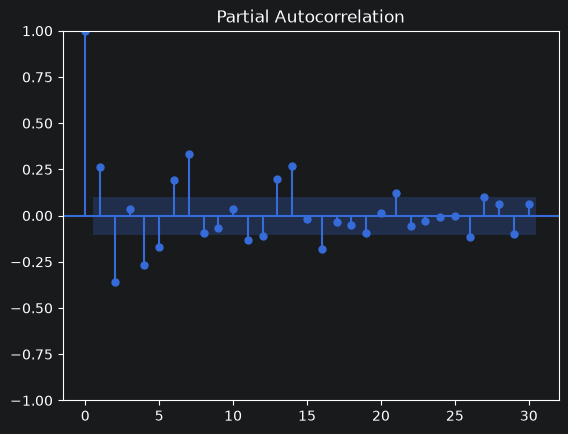

In [29]:
plot_pacf(train_val, lags=30) #lets look at the correlation 30 days in the past
plt.show()

0 is self correlation. 2 might fit (3 is under confidenzintervall (95%)), might try 7

=> p=2 / p=7

#### Parameter q: How many past mistakes should we learn from?

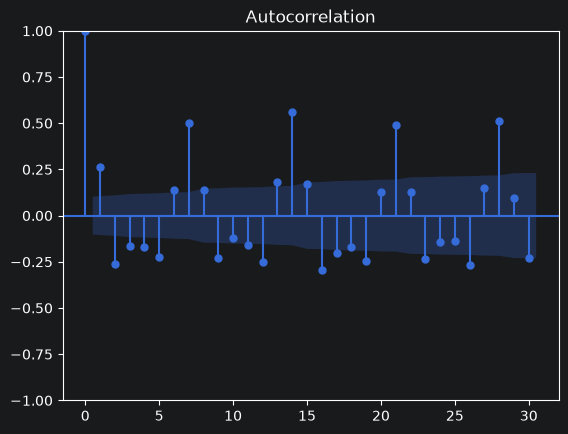

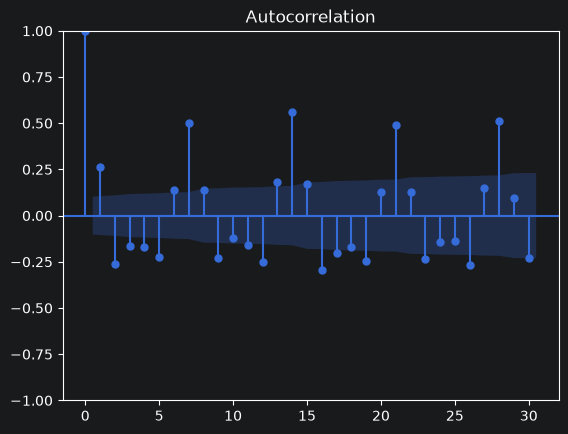

In [31]:
plot_acf(train_val, lags=30)

Looks very very seasonal. Repeating pattern with 7 Days -> weekly pattern. ARIMA is the wrong model, SARIMA would be a better fit. We'll still try ARIMA to compare and find the right hyperparameters. => Let's try q= 7

#### finding the best hyperparameters and training the model

In [32]:
from sklearn.model_selection import GridSearchCV

In [70]:
# trying with d=0, p= 2/7 and q=7
# gridsearch doesn't work for non sklearn models, so we do it manually
results_arima=[]        #to save the results

def best_params (p_list,d_list,q_list): # each one a list with possible parameters, that want to be tested
    warnings.filterwarnings("ignore") #a lot of parameters are not good. i don't want to see the warning for that
    for i in p_list:
        for j in d_list:
            for k in q_list:
                #train
                model_arima = ARIMA(p=i, d=j, q=k)
                model_arima.fit(train)
                forecast_arima=model_arima.predict(len(test))
                #evaluate
                aic=model_arima.model.aic
                mae = mean_absolute_error(test_val,forecast_arima.values().flatten())
                results_arima.append({'parameters': f'p={i},d={j}, q={k}','aic': aic, 'mae': mae})
    return results_arima

In [59]:
best_params([2,7],[0],[7])

D:\Katrin\Bildung und Ausbildung\5. Data Analyst\Python Timeseries\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
D:\Katrin\Bildung und Ausbildung\5. Data Analyst\Python Timeseries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\Katrin\Bildung und Ausbildung\5. Data Analyst\Python Timeseries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[{'parameters': 'p=2,d=0, q=7',
  'aic': np.float64(4593.0506421823875),
  'mae': 114.4067444851239},
 {'parameters': 'p=7,d=0, q=7',
  'aic': np.float64(4519.93608762263),
  'mae': 105.73652324479691}]

In [71]:
#Warnings show not good parameters. Trying another grid, values near the expected ones
best_params([6,7,8],[0,1],[6,7,8])
results_arima= pd.DataFrame(results_arima)
print(results_arima.sort_values('aic').head())
print(results_arima.sort_values('mae').head())

      parameters          aic         mae
5   p=6,d=1, q=8  4503.300125  102.314145
10  p=7,d=1, q=7  4505.637717  104.884188
9   p=7,d=1, q=6  4505.983654  102.749763
11  p=7,d=1, q=8  4506.886616  104.749581
16  p=8,d=1, q=7  4507.160422  101.389378
      parameters          aic         mae
0   p=6,d=0, q=6  4527.373450   99.778332
15  p=8,d=1, q=6  4525.025698  100.047708
6   p=7,d=0, q=6  4513.051685  101.029528
16  p=8,d=1, q=7  4507.160422  101.389378
8   p=7,d=0, q=8  4517.855554  101.624267


although the adf test was stationary, the best results with aic were with d=1:
best aic is (6,1,8); best mae is (6,0,6). aic and mae are all not that different, so I choose nr 16 - it is the only one in both top five lists. so the best parameters are (8,1,7)

In [75]:
model_arima = ARIMA(p=8, d=1, q=7)
model_arima.fit(train)
forecast_arima=model_arima.predict(len(test))

In [77]:
#to compare the models later with the evaluation-metrics
model_evaluation=pd.DataFrame(columns=['model','aic','mae','mse','r2'])

aic=model_arima.model.aic
mae=mean_absolute_error(test_val,forecast_arima.values().flatten())
mse=mean_squared_error(test_val,forecast_arima.values().flatten())
r2= r2_score(test_val,forecast_arima.values().flatten())

#new entry for arima at the End of the DF (len()) with the metrics
model_evaluation.loc[len(model_evaluation)] = ['arima', aic, mae, mse, r2]

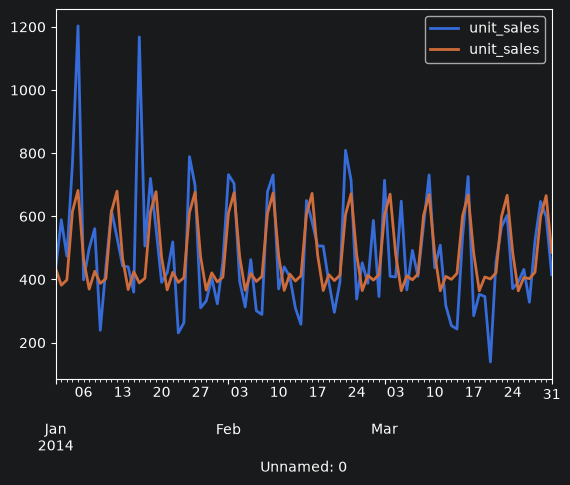

,model,aic,mae,mse,r2
0,arima,4507.160422,101.389378,21117.221404,0.372719


In [79]:
#let's see how it looks like
test.plot()
forecast_arima.plot()
plt.show()
model_evaluation

looks good for a model without seasonality. Let's see how the other models rank

## SARIMA

We already have the parameters p,d,q. Let's find P,D,Q and s/m